# Setting Up Mixed Precision:

In [103]:
from tensorflow.keras import mixed_precision
mixed_precision.set_global_policy(policy= "mixed_float16")

# Importying Necessary Libraries:

In [104]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from tensorflow.keras import Model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv2D, GlobalAveragePooling2D, Flatten, Dropout, Rescaling, Input, RandomFlip, RandomRotation, RandomZoom, RandomHeight, RandomWidth
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import CategoricalCrossentropy, SparseCategoricalCrossentropy
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

# Importing Data from Tensorflow Datasets:

In [105]:
import tensorflow_datasets as tfds

In [106]:
datasets_list = tfds.list_builders()

In [107]:
len(datasets_list)

1278

In [108]:
datasets_list[:10]

['abstract_reasoning',
 'accentdb',
 'aeslc',
 'aflw2k3d',
 'ag_news_subset',
 'ai2_arc',
 'ai2_arc_with_ir',
 'amazon_us_reviews',
 'anli',
 'answer_equivalence']

In [109]:
"oxford_flowers102" in datasets_list

True

In [110]:
# Getting Data:
(train_data, test_data), df_info = tfds.load(name= "oxford_flowers102",
                                             split= ["train", "validation"],
                                             as_supervised= True,
                                             shuffle_files= True,
                                             with_info= True)

# Exploring The Data:

In [111]:
type(df_info)

tensorflow_datasets.core.dataset_info.DatasetInfo

In [112]:
df_info.features

FeaturesDict({
    'file_name': Text(shape=(), dtype=string),
    'image': Image(shape=(None, None, 3), dtype=uint8),
    'label': ClassLabel(shape=(), dtype=int64, num_classes=102),
})

In [113]:
df_info.features["label"].names

['pink primrose',
 'hard-leaved pocket orchid',
 'canterbury bells',
 'sweet pea',
 'english marigold',
 'tiger lily',
 'moon orchid',
 'bird of paradise',
 'monkshood',
 'globe thistle',
 'snapdragon',
 "colt's foot",
 'king protea',
 'spear thistle',
 'yellow iris',
 'globe-flower',
 'purple coneflower',
 'peruvian lily',
 'balloon flower',
 'giant white arum lily',
 'fire lily',
 'pincushion flower',
 'fritillary',
 'red ginger',
 'grape hyacinth',
 'corn poppy',
 'prince of wales feathers',
 'stemless gentian',
 'artichoke',
 'sweet william',
 'carnation',
 'garden phlox',
 'love in the mist',
 'mexican aster',
 'alpine sea holly',
 'ruby-lipped cattleya',
 'cape flower',
 'great masterwort',
 'siam tulip',
 'lenten rose',
 'barbeton daisy',
 'daffodil',
 'sword lily',
 'poinsettia',
 'bolero deep blue',
 'wallflower',
 'marigold',
 'buttercup',
 'oxeye daisy',
 'common dandelion',
 'petunia',
 'wild pansy',
 'primula',
 'sunflower',
 'pelargonium',
 'bishop of llandaff',
 'gaura',

In [114]:
class_names = df_info.features["label"].names

## One Sample from Data:

In [115]:
train_one_sample = train_data.take(1)

In [116]:
train_one_sample

<_TakeDataset element_spec=(TensorSpec(shape=(None, None, 3), dtype=tf.uint8, name=None), TensorSpec(shape=(), dtype=tf.int64, name=None))>

In [117]:
type(train_one_sample)

tensorflow.python.data.ops.take_op._TakeDataset

In [118]:
for image, label in train_one_sample:
  print(f"""
  Image Shape: {image.shape},
  Image Datatype: {image.dtype},
  Class Number: {label},
  Class name: {class_names[label]}""")


  Image Shape: (500, 667, 3),
  Image Datatype: <dtype: 'uint8'>,
  Class Number: 72,
  Class name: water lily


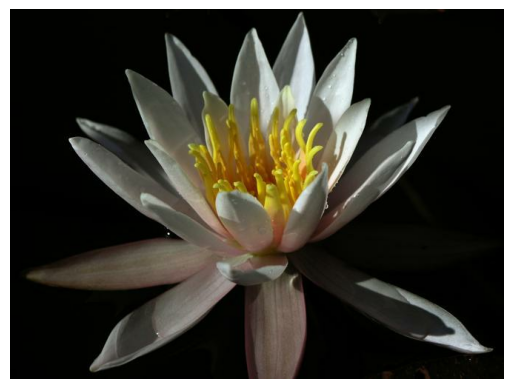

In [119]:
for image, _ in train_one_sample:
  plt.imshow(image)
  plt.axis(False)

In [120]:
image[:5]

<tf.Tensor: shape=(5, 667, 3), dtype=uint8, numpy=
array([[[1, 2, 0],
        [1, 2, 0],
        [1, 2, 0],
        ...,
        [1, 1, 1],
        [1, 1, 1],
        [1, 1, 1]],

       [[1, 2, 0],
        [1, 2, 0],
        [1, 2, 0],
        ...,
        [1, 1, 1],
        [1, 1, 1],
        [1, 1, 1]],

       [[1, 2, 0],
        [1, 2, 0],
        [1, 2, 0],
        ...,
        [1, 1, 1],
        [1, 1, 1],
        [1, 1, 1]],

       [[1, 2, 0],
        [1, 2, 0],
        [1, 2, 0],
        ...,
        [1, 1, 1],
        [1, 1, 1],
        [1, 1, 1]],

       [[1, 2, 0],
        [1, 2, 0],
        [1, 2, 0],
        ...,
        [1, 1, 1],
        [1, 1, 1],
        [1, 1, 1]]], dtype=uint8)>

In [121]:
tf.reduce_min(image), tf.reduce_max(image)

(<tf.Tensor: shape=(), dtype=uint8, numpy=0>,
 <tf.Tensor: shape=(), dtype=uint8, numpy=255>)

## Function to Preprocess The Data:

In [122]:
def preprocess_images(image, label, image_shape= 224):

  # Resizing The Image:
  image = tf.image.resize(images= image, size= [image_shape, image_shape])

  # Changing Datatype of The Image:
  return tf.cast(x= image, dtype= tf.float32), label

In [123]:
# testing The Function:
processed_image = preprocess_images(image, label)[0]
print(f"Before Image: {image[:2]} \nImage Shape: {image.shape} \nImage Datatype: {image.dtype}")
print(f"After Image: {processed_image[:2]} \nImage Shape: {processed_image.shape} \nImage Datatype: {processed_image.dtype}")

Before Image: [[[1 2 0]
  [1 2 0]
  [1 2 0]
  ...
  [1 1 1]
  [1 1 1]
  [1 1 1]]

 [[1 2 0]
  [1 2 0]
  [1 2 0]
  ...
  [1 1 1]
  [1 1 1]
  [1 1 1]]] 
Image Shape: (500, 667, 3) 
Image Datatype: <dtype: 'uint8'>
After Image: [[[1. 2. 0.]
  [1. 2. 0.]
  [1. 2. 0.]
  ...
  [1. 1. 1.]
  [1. 1. 1.]
  [1. 1. 1.]]

 [[1. 2. 0.]
  [1. 2. 0.]
  [1. 2. 0.]
  ...
  [1. 1. 1.]
  [1. 1. 1.]
  [1. 1. 1.]]] 
Image Shape: (224, 224, 3) 
Image Datatype: <dtype: 'float32'>


## Batch and Pre-Procesas The Data:

In [124]:
train_data = train_data.map(map_func = preprocess_images).shuffle(buffer_size= 1000).batch(batch_size= 32).prefetch(buffer_size= tf.data.AUTOTUNE)
test_data = test_data.map(map_func = preprocess_images).shuffle(buffer_size= 1000).batch(batch_size= 32).prefetch(buffer_size= tf.data.AUTOTUNE)

In [125]:
train_data, test_data

(<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int64, name=None))>,
 <_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int64, name=None))>)

# Creating Transfer Learning Model (Feature Vector):

## Model Creation:

In [126]:
# Feature Extraction Model:

input_shape = (224,224,3)

base_model = tf.keras.applications.resnet50.ResNet50(include_top = False)
base_model.trainable= False

# Creating Feature Extractor Model with Functional API:
inputs = Input(shape= input_shape, name= "Input_Layer")
x = base_model(inputs, training= False)
x = GlobalAveragePooling2D(name= "Global_Average_Pool_2D")(x)
output = Dense(len(class_names), activation= "softmax", name= "output_Layer")(x)

model1 = Model(inputs, output)

# Compiling The Model:
model1.compile(optimizer= Adam(),
               loss= SparseCategoricalCrossentropy(),
               metrics= ["accuracy"])

In [127]:
model1.summary()

Model: "model_6"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 Input_Layer (InputLayer)    [(None, 224, 224, 3)]     0         
                                                                 
 resnet50 (Functional)       (None, None, None, 2048   23587712  
                             )                                   
                                                                 
 Global_Average_Pool_2D (Gl  (None, 2048)              0         
 obalAveragePooling2D)                                           
                                                                 
 output_Layer (Dense)        (None, 102)               208998    
                                                                 
Total params: 23796710 (90.78 MB)
Trainable params: 208998 (816.40 KB)
Non-trainable params: 23587712 (89.98 MB)
_________________________________________________________________


In [128]:
# Fitting The Model:
history_1 = model1.fit(train_data,
                       validation_data= test_data,
                       epochs= 5,
                       validation_steps= int(0.1 * len(test_data)))

Epoch 1/5
32/32 [==============================] - 14s 150ms/step - loss: 4.4001 - accuracy: 0.1314 - val_loss: 2.8906 - val_accuracy: 0.3333
Epoch 2/5
32/32 [==============================] - 9s 219ms/step - loss: 1.6480 - accuracy: 0.6804 - val_loss: 1.6774 - val_accuracy: 0.6771
Epoch 3/5
32/32 [==============================] - 6s 120ms/step - loss: 0.7547 - accuracy: 0.9147 - val_loss: 1.2012 - val_accuracy: 0.6771
Epoch 4/5
32/32 [==============================] - 6s 145ms/step - loss: 0.4114 - accuracy: 0.9804 - val_loss: 1.0291 - val_accuracy: 0.8229
Epoch 5/5
32/32 [==============================] - 10s 226ms/step - loss: 0.2589 - accuracy: 0.9892 - val_loss: 1.0070 - val_accuracy: 0.7812


## Evaluating The Model:

In [129]:
model1.evaluate(test_data)

32/32 [==============================] - 3s 50ms/step - loss: 0.9681 - accuracy: 0.7922


[0.9680913090705872, 0.7921568751335144]

In [130]:
history_1.history.keys()

dict_keys(['loss', 'accuracy', 'val_loss', 'val_accuracy'])

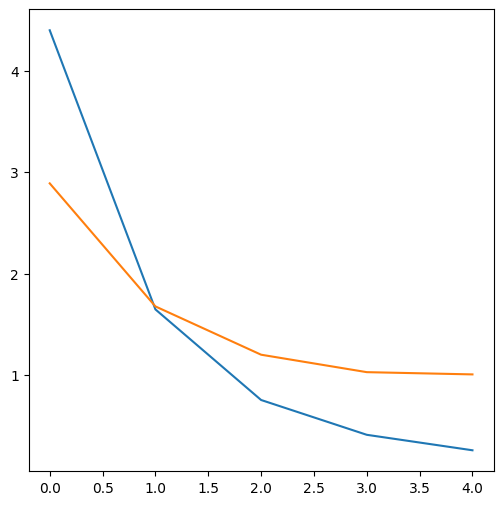

In [131]:
# Plotting Loss:
plt.figure(figsize= (6,6))
plt.plot(history_1.history["loss"])
plt.plot(history_1.history["val_loss"])
plt.show()

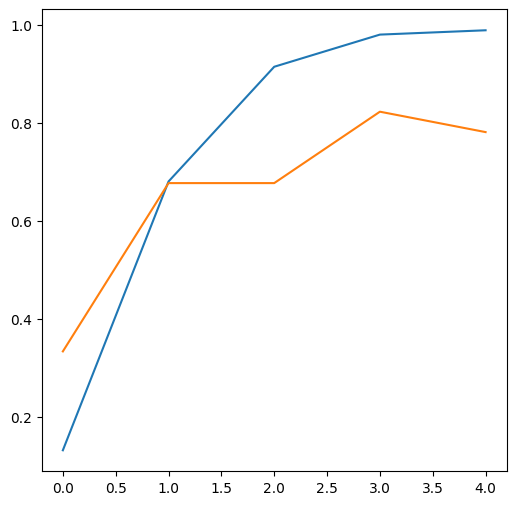

In [132]:
# Plotting Accuracy:
plt.figure(figsize= (6,6))
plt.plot(history_1.history["accuracy"])
plt.plot(history_1.history["val_accuracy"])
plt.show()

# Data Augmentation:

## Creting a Sequential Model for Data Augmentation:

In [133]:
data_augmentation = Sequential(name= "Data_Augmentation")
data_augmentation.add(RandomFlip(mode= "horizontal"))
data_augmentation.add(RandomRotation(factor= 0.2))
data_augmentation.add(RandomZoom(height_factor= 0.2))
data_augmentation.add(RandomHeight(factor= 0.2))
data_augmentation.add(RandomWidth(factor= 0.2))

## Creating Same Model as Model 1 with Augmented Data:

In [134]:
# Feature Extraction Model:

input_shape = (224,224,3)

base_model = tf.keras.applications.resnet50.ResNet50(include_top = False)
base_model.trainable= False

# Creating Feature Extractor Model with Functional API:
inputs = Input(shape= input_shape, name= "Input_Layer")
x = data_augmentation(inputs)
x = base_model(x, training= False)
x = GlobalAveragePooling2D(name= "Global_Average_Pool_2D")(x)
output = Dense(len(class_names), activation= "softmax", name= "output_Layer")(x)

model2 = Model(inputs, output)

# Compiling The Model:
model2.compile(optimizer= Adam(),
               loss= SparseCategoricalCrossentropy(),
               metrics= ["accuracy"])

In [135]:
model2.summary()

Model: "model_7"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 Input_Layer (InputLayer)    [(None, 224, 224, 3)]     0         
                                                                 
 Data_Augmentation (Sequent  (None, None, None, 3)     0         
 ial)                                                            
                                                                 
 resnet50 (Functional)       (None, None, None, 2048   23587712  
                             )                                   
                                                                 
 Global_Average_Pool_2D (Gl  (None, 2048)              0         
 obalAveragePooling2D)                                           
                                                                 
 output_Layer (Dense)        (None, 102)               208998    
                                                           

In [136]:
# Fitting The Model:
history_2 = model2.fit(train_data,
                       validation_data= test_data,
                       epochs= 5,
                       validation_steps= int(0.1 * len(test_data)))

Epoch 1/5
32/32 [==============================] - 60s 2s/step - loss: 4.5423 - accuracy: 0.0784 - val_loss: 3.0911 - val_accuracy: 0.2604
Epoch 2/5
32/32 [==============================] - 38s 1s/step - loss: 2.5566 - accuracy: 0.4647 - val_loss: 2.0443 - val_accuracy: 0.5000
Epoch 3/5
32/32 [==============================] - 39s 1s/step - loss: 1.7347 - accuracy: 0.6490 - val_loss: 1.6286 - val_accuracy: 0.6771
Epoch 4/5
32/32 [==============================] - 29s 843ms/step - loss: 1.2819 - accuracy: 0.7676 - val_loss: 1.3132 - val_accuracy: 0.6771
Epoch 5/5
32/32 [==============================] - 32s 980ms/step - loss: 0.9382 - accuracy: 0.8373 - val_loss: 1.1800 - val_accuracy: 0.7188


## Evaluationg The Model:

In [137]:
model2.evaluate(test_data)

32/32 [==============================] - 4s 56ms/step - loss: 1.1899 - accuracy: 0.7186


[1.1898858547210693, 0.7186274528503418]

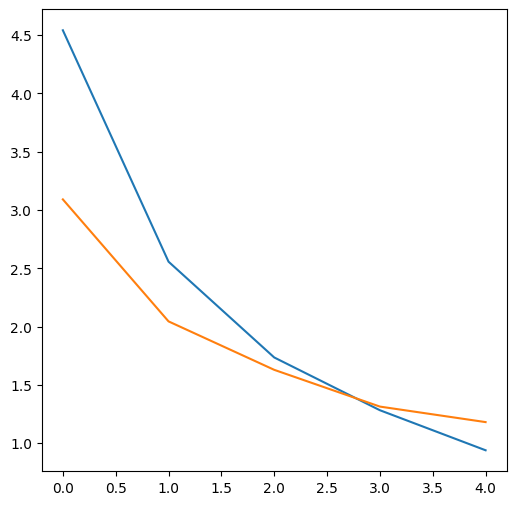

In [138]:
# Plotting Loss:
plt.figure(figsize= (6,6))
plt.plot(history_2.history["loss"])
plt.plot(history_2.history["val_loss"])
plt.show()

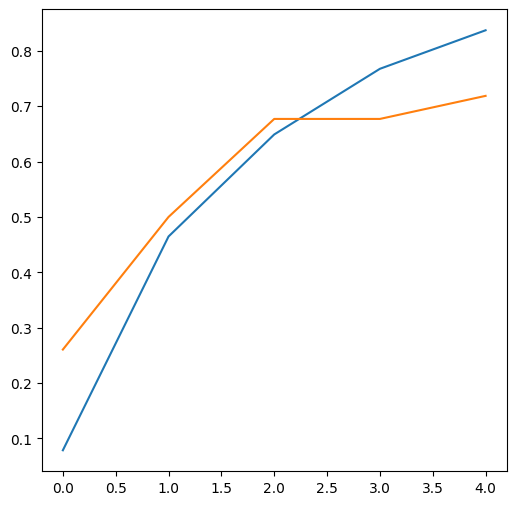

In [139]:
# Plotting Accuracy:
plt.figure(figsize= (6,6))
plt.plot(history_2.history["accuracy"])
plt.plot(history_2.history["val_accuracy"])
plt.show()

# Fine Tuning Model 2:

## Un-Freezing Last 10 Layers og Base Model (Resnet50):

In [140]:
# Checking which Layers of Base Model are Trainable:
model2.layers

In [142]:
for layer in model2.layers[2].layers:
  print(f"Layer Name: {layer.name}, Trainable?: {layer.trainable}")

Layer Name: input_8, Trainable?: False
Layer Name: conv1_pad, Trainable?: False
Layer Name: conv1_conv, Trainable?: False
Layer Name: conv1_bn, Trainable?: False
Layer Name: conv1_relu, Trainable?: False
Layer Name: pool1_pad, Trainable?: False
Layer Name: pool1_pool, Trainable?: False
Layer Name: conv2_block1_1_conv, Trainable?: False
Layer Name: conv2_block1_1_bn, Trainable?: False
Layer Name: conv2_block1_1_relu, Trainable?: False
Layer Name: conv2_block1_2_conv, Trainable?: False
Layer Name: conv2_block1_2_bn, Trainable?: False
Layer Name: conv2_block1_2_relu, Trainable?: False
Layer Name: conv2_block1_0_conv, Trainable?: False
Layer Name: conv2_block1_3_conv, Trainable?: False
Layer Name: conv2_block1_0_bn, Trainable?: False
Layer Name: conv2_block1_3_bn, Trainable?: False
Layer Name: conv2_block1_add, Trainable?: False
Layer Name: conv2_block1_out, Trainable?: False
Layer Name: conv2_block2_1_conv, Trainable?: False
Layer Name: conv2_block2_1_bn, Trainable?: False
Layer Name: con

In [147]:
# Un-Freezing last 10 Layers of base Model:
for layer in model2.layers[2].layers[-10:]:
  layer.trainable= True

In [148]:
for layer in model2.layers[2].layers:
  print(f"Layer Name: {layer.name}, Trainable?: {layer.trainable}")

Layer Name: input_8, Trainable?: False
Layer Name: conv1_pad, Trainable?: False
Layer Name: conv1_conv, Trainable?: False
Layer Name: conv1_bn, Trainable?: False
Layer Name: conv1_relu, Trainable?: False
Layer Name: pool1_pad, Trainable?: False
Layer Name: pool1_pool, Trainable?: False
Layer Name: conv2_block1_1_conv, Trainable?: False
Layer Name: conv2_block1_1_bn, Trainable?: False
Layer Name: conv2_block1_1_relu, Trainable?: False
Layer Name: conv2_block1_2_conv, Trainable?: False
Layer Name: conv2_block1_2_bn, Trainable?: False
Layer Name: conv2_block1_2_relu, Trainable?: False
Layer Name: conv2_block1_0_conv, Trainable?: False
Layer Name: conv2_block1_3_conv, Trainable?: False
Layer Name: conv2_block1_0_bn, Trainable?: False
Layer Name: conv2_block1_3_bn, Trainable?: False
Layer Name: conv2_block1_add, Trainable?: False
Layer Name: conv2_block1_out, Trainable?: False
Layer Name: conv2_block2_1_conv, Trainable?: False
Layer Name: conv2_block2_1_bn, Trainable?: False
Layer Name: con

## Recompling The Model with Lower Learning Rate:

In [149]:
model2.compile(optimizer= Adam(0.0001),
               loss= SparseCategoricalCrossentropy(),
               metrics= ["accuracy"])

## Fine-Tuning Model 2:

In [150]:
history_2_fine_tuned = model2.fit(train_data,
                                  validation_data= test_data,
                                  epochs= 10,
                                  initial_epoch = history_2.epoch[-1],
                                  validation_steps= int(0.1 * len(test_data)))

Epoch 5/10
32/32 [==============================] - 40s 1s/step - loss: 0.8708 - accuracy: 0.8598 - val_loss: 1.3519 - val_accuracy: 0.6458
Epoch 6/10
32/32 [==============================] - 33s 978ms/step - loss: 0.7675 - accuracy: 0.9108 - val_loss: 1.0150 - val_accuracy: 0.7500
Epoch 7/10
32/32 [==============================] - 24s 715ms/step - loss: 0.6767 - accuracy: 0.9039 - val_loss: 0.7463 - val_accuracy: 0.8542
Epoch 8/10
32/32 [==============================] - 25s 696ms/step - loss: 0.7066 - accuracy: 0.9088 - val_loss: 0.8976 - val_accuracy: 0.8021
Epoch 9/10
32/32 [==============================] - 24s 718ms/step - loss: 0.6767 - accuracy: 0.9216 - val_loss: 0.8529 - val_accuracy: 0.8125
Epoch 10/10
32/32 [==============================] - 26s 736ms/step - loss: 0.6548 - accuracy: 0.9186 - val_loss: 0.9733 - val_accuracy: 0.8125


## Evaluating Fine Tuned Model:

In [151]:
model2.evaluate(test_data)

32/32 [==============================] - 5s 51ms/step - loss: 1.0068 - accuracy: 0.7627


[1.0067708492279053, 0.7627450823783875]

## Comparing Feature Extraction and Fine-Tuned Model:

[0, 1, 2, 3, 4]

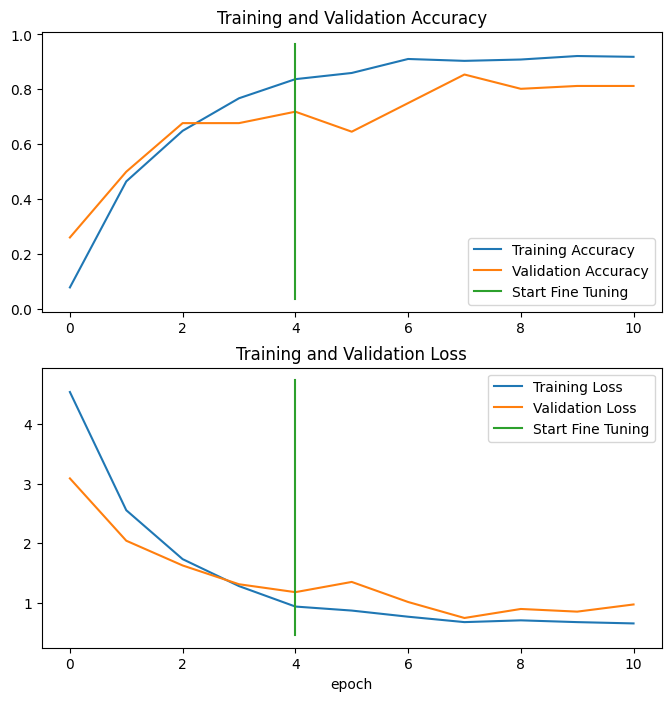

In [158]:
# Get original history measurements
acc = history_2.history["accuracy"]
loss = history_2.history["loss"]

val_acc = history_2.history["val_accuracy"]
val_loss = history_2.history["val_loss"]

# Combine original history with new history
total_acc = acc + history_2_fine_tuned.history["accuracy"]
total_loss = loss + history_2_fine_tuned.history["loss"]

total_val_acc = val_acc + history_2_fine_tuned.history["val_accuracy"]
total_val_loss = val_loss + history_2_fine_tuned.history["val_loss"]

# Make plots
plt.figure(figsize=(8, 8))
plt.subplot(2, 1, 1)
plt.plot(total_acc, label='Training Accuracy')
plt.plot(total_val_acc, label='Validation Accuracy')
plt.plot([len(history_2.epoch)-1, len(history_2.epoch)-1],
              plt.ylim(), label='Start Fine Tuning') # reshift plot around epochs
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(2, 1, 2)
plt.plot(total_loss, label='Training Loss')
plt.plot(total_val_loss, label='Validation Loss')
plt.plot([len(history_2.epoch)-1, len(history_2.epoch)-1],
              plt.ylim(), label='Start Fine Tuning') # reshift plot around epochs
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.xlabel('epoch')
plt.show()